<a href="https://colab.research.google.com/github/Plumz17/CVL_Assignment04/blob/main/CVL_Assignment04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Fourth Computer Vision Assignment - Analysis of Object Detection Algorithm - Anders Emmanuel Tan (24/541351/PA/22964)
Description: In this Assignment I will be Implementing two several Object Tracking Methods (Template Matching and Optical Flow) in order to track a person within a video. Additionally, I will be manually implementing evaluation metrics in order to evaluate and analyze the performance of both methods.

For this assignment, i will be using an Object Tracking Benchmark (OTB) dataset from kaggle as can be seen in this link: (https://www.kaggle.com/datasets/zly1402875051/otb2015). Since the files provided in the dataset are in the form of multiple .jpg files, we will also be providing a function that converts those into video file so we can illustrate the algorithm's performance (since videos are just sequences of frames)

## 0. Setting Up
Description: For this first section, we will be preparing the frames that will later be processed. Since the uploaded files in Google Colab are only available in the runtime, I will be attaining those files by acquiring them from my mounted google drive folder (which contains a folder with all of the frames as well as a .txt file containing the information of the bounding boxes). Additionaly, we will also be importing the libaries that we will be using for this submission to import and process the frames. We will also be defining some helper functions to aid us in our implementation later (including one that'll combine every frame into a video)

### 0A. Importing the Files

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import Important Libraries
import cv2 # For Reading Image
import numpy as np # For Manipulating Numeric types
import matplotlib.pyplot as plt # For Showing Image
import math # For Math
import os # For managing files

#Loading File using their Filenames
filename_video    = "/content/drive/MyDrive/CVL_Files/Video"
filename_video_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_rect.txt"

In [ ]:
def load_frames_from_folder(folder_path):
  # Get all filenames and sort them
  frame_files = sorted(os.listdir(folder_path))
  frames = []
  for file in frame_files:
    file_path = os.path.join(folder_path, file)

    # Read image
    img = cv2.imread(file_path)

    # Convert to grayscale for ease and append it to frames
    if img is not None:
      img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
      frames.append(img)

  return frames

In [ ]:
def load_ground_truth(gt_path):
  gt = []
  with open(gt_path, 'r') as f:
    for line in f:
      # Dataset ground truth is tab seperated
      line = line.strip()
      values = [float(v) for v in line.split('	') if v != '']
      # Each line is x, y, width, height
      gt.append(values[:4])
  return np.array(gt, dtype=np.float32)

frames = load_frames_from_folder(filename_video)
gt_boxes  = load_ground_truth(filename_video_gt)

### 0B. Defining Helper Functions

In [ ]:
def show(img): # Helper function to show frame
  if len(img.shape) == 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)
  plt.imshow(img, cmap='gray', vmin=0, vmax=255) #vmin and max to preserve original image's contrast
  plt.title("Original")
  plt.axis("off")
  plt.show()

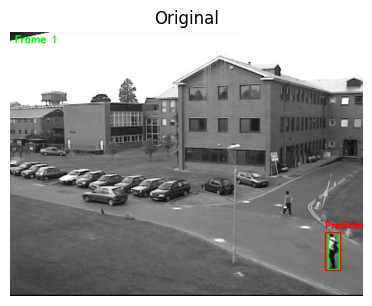

In [ ]:
def draw_ground_truth(frames, gt_boxes, frame_idx):
  # Change back to BGR since we want a colored box
  annotated_frame = cv2.cvtColor(frames[frame_idx], cv2.COLOR_GRAY2BGR)
  # Unpack the the gt_box
  x, y, w, h = [int(v) for v in gt_boxes[frame_idx]]

  cv2.rectangle(annotated_frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
  cv2.putText(annotated_frame, f"Frame {frame_idx+1}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
  return annotated_frame

# Pass the frames and gt_boxes and the index of that specific frame
annotated_frame = draw_ground_truth(frames, gt_boxes, 0)

def draw_pred_box(frames, gt_boxes, pred_box, frame_idx):
  # Show GT box too
  annotated_frame = draw_ground_truth(frames, gt_boxes, frame_idx)
  # Unpack predicted box
  x, y, w, h = [int(v) for v in pred_box]

  # Draw predicted box in red
  cv2.rectangle(annotated_frame, (x, y), (x+w, y+h), (0, 0, 255), 2)
  cv2.putText(annotated_frame, "Predicted", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

  return annotated_frame

predicted_frame = draw_pred_box(frames, gt_boxes, gt_boxes[1], frame_idx=0)

show(predicted_frame)

In [ ]:
#Helper Function to play the frames as a video
def save_frames_as_video(frames, filename, output_path="/content", fps=30, with_gt = False):
  h, w = frames[0].shape[:2]
  # Define video writer
  fourcc = cv2.VideoWriter_fourcc(*'mp4v')
  full_path = f"{output_path}/{filename}.mp4"
  out = cv2.VideoWriter(full_path, fourcc, fps, (w, h), isColor=with_gt)
  for i, frame in enumerate(frames):
    if with_gt:
      # Use the thre previous function
      out_frame = draw_ground_truth(frames, gt_boxes, i)
    else:
      out_frame = frame
    out.write(out_frame)
  out.release()

save_frames_as_video(frames, "output_gt", with_gt=True)

## 1. Template Matching

### 1A. Template Matching Implementation

### 1B. Template Matching Evaluation

### 1C. Optical Flow Analysis
Analysis:

## 2. Optical Flow
Description:

### 2A. Optical Flow Implementation

### 2B. Optical Flow Evaluation

### 2C. Optical Flow Analysis
Analysis: